# Week 5 – Day 1  
## Linear Regression on Medical Cost Dataset
# Author : Mir Musaib. 

This notebook implements a Linear Regression model to predict medical insurance charges using demographic and lifestyle features. The workflow includes preprocessing, encoding, scaling, model training, evaluation, and diagnostic analysis.


## Objective

The objective of this analysis is to:

- Apply supervised learning using Linear Regression.
- Predict medical insurance charges based on demographic and health-related factors.
- Evaluate model performance using R², MAE, and MSE.
- Diagnose model assumptions using residual analysis.
- Improve performance using feature engineering and log transformation.


In [71]:
import pandas as pd

In [72]:
df = pd.read_csv("C:\\Users\\mimusaib\\Desktop\\Data_Science_Internship\\Week_5\\Dataset\\insurance.csv")

In [73]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [75]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


## Exploratory Data Analysis

We begin by examining summary statistics and understanding the distribution of features.

Key observations:
- Charges are highly variable.
- Presence of high-cost outliers.
- Smoking status is expected to significantly impact medical charges.


In [76]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

## Dataset Overview

The dataset contains information about individuals and their medical insurance charges.

### Features:
- age: Age of the individual
- sex: Gender
- bmi: Body Mass Index
- children: Number of dependents
- smoker: Smoking status
- region: Residential region

### Target Variable:
- charges: Medical insurance cost


In [77]:
X = df.drop('charges', axis=1)
import numpy as np
y = np.log(df['charges'])


## Log Transformation of Target Variable

Medical charges exhibit right-skewness and high variance.

To stabilize variance and improve linearity, we apply a log transformation to the target variable:

y = log(charges)

Benefits:
- Reduces skewness
- Minimizes impact of extreme values
- Improves homoscedasticity


In [78]:
X = pd.get_dummies(X, drop_first=True)


In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [80]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [81]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


## Model Training – Linear Regression

We train a Linear Regression model on the scaled training data.

The model estimates the relationship between features and the log-transformed target variable.


In [82]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))


R2 Score: 0.8047311493462985
MAE: 0.26969163500404647
MSE: 0.17557416396791667


## Model Evaluation

The model is evaluated using:

- R² Score – Measures variance explained
- MAE – Mean Absolute Error
- MSE – Mean Squared Error

Results:
R² ≈ 0.80

Interpretation:
The model explains approximately 80% of the variance in log-transformed medical charges.


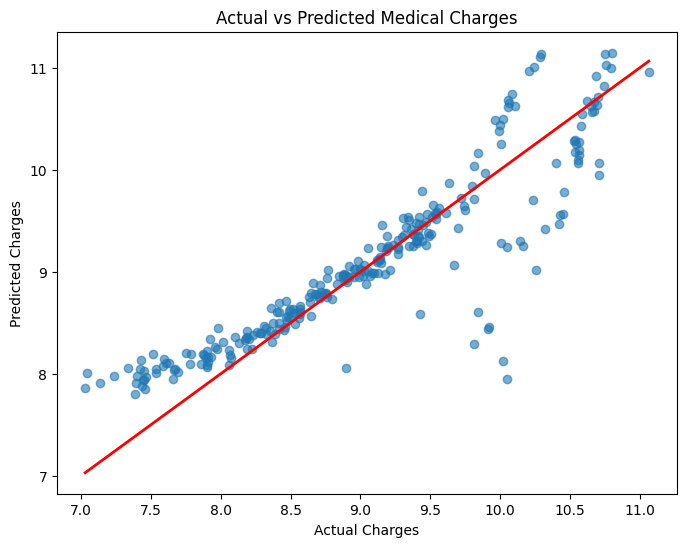

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Medical Charges")

# Add perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.show()


## Actual vs Predicted Values

This scatter plot compares actual and predicted values.

A strong model will show points closely aligned along the diagonal reference line.

Observation:
The model demonstrates strong predictive alignment with some dispersion due to high-cost cases.


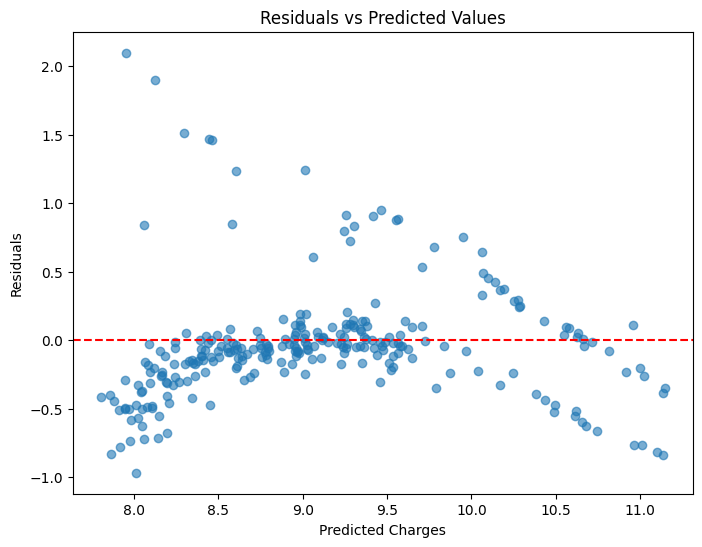

In [84]:
residuals = y_test - y_pred
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Charges")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()


## Residual Analysis

Residuals = Actual − Predicted

We analyze:

1. Residuals vs Predicted plot
2. Distribution of residuals

Observations:
- Residuals are centered around zero.
- Variance is more stable after log transformation.
- Slight dispersion remains at higher predicted values.


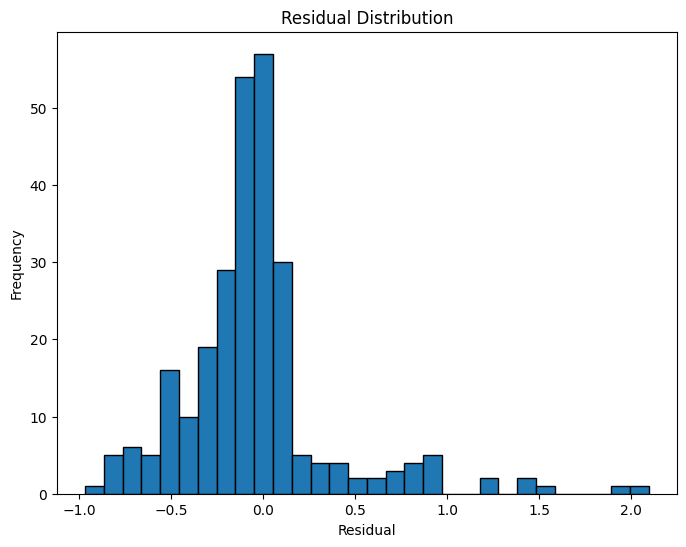

In [85]:
plt.figure(figsize=(8,6))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residual Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


## Conclusion

The initial model using limited features resulted in low predictive performance (R² ≈ 0.15).

After incorporating categorical variables and applying log transformation, model performance improved significantly (R² ≈ 0.80).

This demonstrates:

- Importance of feature selection
- Impact of categorical encoding
- Value of log transformation in skewed datasets
- Proper preprocessing pipeline improves regression performance

The model is suitable for predictive analysis with reasonable accuracy.


## Future Improvements

- Perform cross-validation
- Check multicollinearity using VIF
- Try Regularized Regression (Ridge / Lasso)
- Experiment with interaction features
- Compare with non-linear models
